
**TASK 1: LOAD AND INSPECT THE DIABETIC_DATA.CSV DATASET**

In [ ]:
# Step 1: Load the required libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Step 2: Load diabetic_data.csv into a panda DataFrame
df = pd.read_csv("diabetic_data.csv", low_memory=False)


In [ ]:
#Step 3: DISPLAY THE FIRST FIVE ROWS OF THE DATASET
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# STEP 4: DISPLAY THE STRUCTURE OF THE DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
#Step 5: DISPLAY THE LIST OF COLUMNS IN THE DATASET.
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [ ]:
# STEP 6 BRIEFLY REPORT THE NUMBER OF ROWS AND COLOUMNS IN THE DATASET


#### The overview of the structure 


* The dataframe contains 101766 entries
* The total number of columns is 50
* The data type: 13 int(64) and 37 objects

The dataset contains hospital records of patients diagnosed with Diabetes Melltius. Each row shows a single patient visit. It includes details about the patient's background, medical history, treatments received, and the results from the hospital.

The dataset consists of both numerical and categorical variables. Numerical variables include attributes such as time in hospital and number of procedures, while categorical variables include gender, race, and admission type.

The `df.info()` output shows the data types of each column, as well as the presence of any missing values. This is important for understanding data quality and preparing for further analysis.

The dataset contains multiple attributes related to patient characteristics, hospital interactions, and treatment details. These variables will be used to explore patterns related to hospital readmissions.



**Task 2: DATA CLEANING, ANALYTICAL PREPARATION AND FEATURE CREATION**

In [ ]:
#Step 1: IDENTIFY DATA-QUALITY ISSUES IN THE REQUIRED VARIABLES
selected_cols = [
    'patient_nbr',
    'readmitted',
    'admission_type_id',
    'medical_specialty',
    'num_medications',
    'time_in_hospital',
    'age',
    'gender',
    'race'
    
]

df_selected = df[selected_cols].copy()

df_id_maps = pd.read_excel("id_mapping.xlsx")




df_selected = df_selected.merge( 
    df_id_maps, 
    on="admission_type_id", 
 
    how="left" 
) 




df_selected=df_selected.rename(columns={"description":"admission_type"})

In [ ]:
df_selected["race"].unique()

array(['Caucasian', 'AfricanAmerican', nan, 'Other', 'Asian', 'Hispanic'],
      dtype=object)

In [ ]:
df_selected["gender"].unique()

array(['Female', 'Male', 'Unknown/Invalid'], dtype=object)

In [ ]:
df_selected["age"].unique()

array(['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)',
       '[60-70)', '[70-80)', '[80-90)', '[90-100)'], dtype=object)

In [ ]:
df_selected["readmitted"].unique()


array(['NO', '>30', '<30'], dtype=object)

In [ ]:
df_selected["medical_specialty"].unique()

array(['Pediatrics-Endocrinology', nan, 'InternalMedicine',
       'Family/GeneralPractice', 'Cardiology', 'Surgery-General',
       'Orthopedics', 'Gastroenterology',
       'Surgery-Cardiovascular/Thoracic', 'Nephrology',
       'Orthopedics-Reconstructive', 'Psychiatry', 'Emergency/Trauma',
       'Pulmonology', 'Surgery-Neuro',
       'Obsterics&Gynecology-GynecologicOnco', 'ObstetricsandGynecology',
       'Pediatrics', 'Hematology/Oncology', 'Otolaryngology',
       'Surgery-Colon&Rectal', 'Pediatrics-CriticalCare', 'Endocrinology',
       'Urology', 'Psychiatry-Child/Adolescent', 'Pediatrics-Pulmonology',
       'Neurology', 'Anesthesiology-Pediatric', 'Radiology',
       'Pediatrics-Hematology-Oncology', 'Psychology', 'Podiatry',
       'Gynecology', 'Oncology', 'Pediatrics-Neurology',
       'Surgery-Plastic', 'Surgery-Thoracic',
       'Surgery-PlasticwithinHeadandNeck', 'Ophthalmology',
       'Surgery-Pediatric', 'Pediatrics-EmergencyMedicine',
       'PhysicalMedicineandRe

In [ ]:

df_selected["time_in_hospital"].unique()

array([ 1,  3,  2,  4,  5, 13, 12,  9,  7, 10,  6, 11,  8, 14])

In [ ]:
df_selected.head()

,patient_nbr,readmitted,admission_type_id,medical_specialty,num_medications,time_in_hospital,age,gender,race,admission_type
0,8222157,NO,6,Pediatrics-Endocrinology,1,1,[0-10),Female,Caucasian,NaN
1,55629189,>30,1,NaN,18,3,[10-20),Female,Caucasian,Emergency
2,86047875,NO,1,NaN,13,2,[20-30),Female,AfricanAmerican,Emergency
3,82442376,NO,1,NaN,16,2,[30-40),Male,Caucasian,Emergency
4,42519267,NO,1,NaN,8,1,[40-50),Male,Caucasian,Emergency


* The medical_specialty contains NaN, which means the dataset is incomplete and needs data cleaning and filling of the missing data.
* The readmitted status NO, <30 and > 30, the NO should be " No readmission", the <30 should be " Readmission < 30 days " and the >30 should be " Readmission > 30 days."
* The nullable values in the race should be classified as "Other."
* The medical_specialty has more distinct values, and it is much more difficult to visualise. 

In [ ]:
#Step 2: Check for missing values
df_selected.isnull().sum()

patient_nbr              0
readmitted               0
admission_type_id        0
medical_specialty    49949
num_medications          0
time_in_hospital         0
age                      0
gender                   0
race                  2273
admission_type        5291
dtype: int64

- The `medical_specialty` variable contains 49,949 missing values.
- The `race` variable contains 2,273 missing values.
- The `gender` does have nulls and was classified as unknown/invalid. 
- All other variables, including `readmitted`, `num_medications`, `time_in_hospital`, `age`, and `gender`, do not contain missing values.


In [ ]:
df_selected.isnull().mean()

patient_nbr          0.000000
readmitted           0.000000
admission_type_id    0.000000
medical_specialty    0.490822
num_medications      0.000000
time_in_hospital     0.000000
age                  0.000000
gender               0.000000
race                 0.022336
admission_type       0.051992
dtype: float64

* The results show that the `medical_specialty` variable contains a high proportion of missing values (approximately *49%*).
* The `race` variable contains a relatively small proportion of missing values (approximately *2%*).
* All other variables, including `readmitted`, `num_medications`, `time_in_hospital`, `age`, and `gender`, contain no missing values, indicating high data completeness and reliability.

Therefore,  `medical_specialty` and `race` are the only variables that contain missing values. 

In [ ]:
# Fill the missing values.
df_selected["race"].fillna("Not_specified",inplace=True)
df_selected["race"]=df_selected["race"].str.replace("Other","Not_specified")
df_selected["medical_specialty"]=df_selected["medical_specialty"].fillna("Not_specified")
df_selected["gender"]=df_selected["gender"].str.replace({"Unknown/Invalid","Not_specified"})
df_selected["admission_type"]=df_selected["admission_type"].fillna("Not_specified")

In [ ]:
# Correcting the data type, we have float64, int64 and string/object.
print("\nDataset structure:")
df_selected.info()


Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   patient_nbr        101766 non-null  int64 
 1   readmitted         101766 non-null  object
 2   admission_type_id  101766 non-null  int64 
 3   medical_specialty  101766 non-null  object
 4   num_medications    101766 non-null  int64 
 5   time_in_hospital   101766 non-null  int64 
 6   age                101766 non-null  object
 7   gender             3 non-null       object
 8   race               1506 non-null    object
 9   admission_type     101766 non-null  object
dtypes: int64(4), object(6)
memory usage: 7.8+ MB



**DATASET STRUCTURE**

#### The structure of the dataset is examined the correct data types, and find missing values #### 

**Interpretation of the dataset Structure**
* The dataframe contains 101,766 records and 9 variables.
* There's a total of 9 columns 
* 4 int64, 5 objects
* `medical_specialty` has only 51,817 non-null values, and the `race`variable has *99,493* non-null values out of 101,766 records. This means there's a large number of missing values. 
* medical_specialty = **51817** non-null
* race = **99493 non-null
* The variables include: Patient identifiers, readmission outcome, admission type, medical specialty, medication count, time in hospital, age, gender, and race.



In [ ]:
# The patient_nbr and the admission_type_id are identifiers, so they need to be objects. 
df_selected["patient_nbr"]=df_selected["patient_nbr"].astype(str)
df_selected["admission_type_id"]=df_selected["admission_type_id"].astype(str)

In [ ]:
#Step 3: Age-group categories
df_selected["age"].value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

We have many age groupies to catogaries so we have to group them in pairs.

In [ ]:
df_selected["age"]=df_selected["age"].map({"[0-10)":"0-20","[10-20)":"0-20",
                                           "[20-30)":"20-40","[30-40)":"20-40",
                                           "[40-50)": "40-60","[50-60)":"40-60",
                                           "[60-70)":"60-80","[70-80)":"60-80" 
                                          })
                                        
                                           
                                           

In [ ]:
#Step 4: Encounters per patient.
df["no_of_encounters"]=df.groupby('patient_nbr')['patient_nbr'].transform("count")

# Task 3: Visual Analysis Planning


**1.What is the distribution of the readmission category, with particular focus on whether a
patient was readmitted within 30 days of discharge?**


* The question is descriptive because it summarizes the record but does not compare.
* The visual is going to be a counter bar chart.
* The attribute used is going to be **readmitted**
* The counter bar chart will help us to compare the readmitted category easily and it is easily understandable and explainable.    



**2. How does the readmission category vary by admission type? In particular, which admission
types have a higher proportion of early readmissions?**

* The question is descriptive because it summarizes the record but does not compare.
* The visual is going to be a counter bar chart.
* The attribute used is going to be **readmitted**
* The counter bar chart will help us to compare the readmitted category easily and it is easily understandable and explainable.
  
**3. How does the readmission category vary across age group and gender?**
* The question is descriptive because it summarizes the record but does not compare.
* The visual is going to be a counter bar chart.
* The attribute used is going to be **readmitted**
* The counter bar chart will help us to compare the readmitted category easily and it is easily understandable and explainable.
  
**4. How does time in hospital vary across readmission categories? In particular, do patients
readmitted within 30 days tend to have different lengths of stay?**

* The question is descriptive because it summarizes the record but does not compare.
* The visual is going to be a counter bar chart.
* The attribute used is going to be **readmitted**
* The counter bar chart will help us to compare the readmitted category easily and it is easily understandable and explainable.
  
**5. How does the distribution of the number of medications vary by readmission category?**

* The question is descriptive because it summarizes the record but does not compare.
* The visual is going to be a counter bar chart.
* The attribute used is going to be **readmitted**
* The counter bar chart will help us to compare the readmitted category easily and it is easily understandable and explainable.    
 
**6. How do treatment-intensity patterns, as measured by the average number of medications,
vary across readmission categories and racial groups?**

* The question is descriptive because it summarizes the record but does not compare.
* The visual is going to be a counter bar chart.
* The attribute used is going to be **readmitted**
* The counter bar chart will help us to compare the readmitted category easily and it is easily understandable and explainable.    

**7. How does the proportion of early readmission vary by number of encounters per patient?
This visualisation must be based on unique patients rather than on encounter-level rows.**

* The question is descriptive because it summarizes the record but does not compare.
* The visual is going to be a counter bar chart.
* The attribute used is going to be **readmitted**
* The counter bar chart will help us to compare the readmitted category easily and it is easily understandable and explainable.    

**8. Which medical specialty most frequently admits these patients?
For this visualisation, you may exclude missing, unknown, or invalid medical specialty
values, provided that your decision is clearly justified and documented.**

* The question is descriptive because it summarizes the record but does not compare.
* The visual is going to be a counter bar chart.
* The attribute used is going to be **readmitted**
* The counter bar chart will help us to compare the readmitted category easily and it is easily understandable and explainable.    




# Task 4: visulisation Construction.


Text(0.5, 1.0, 'Distribution of Readmitted category')

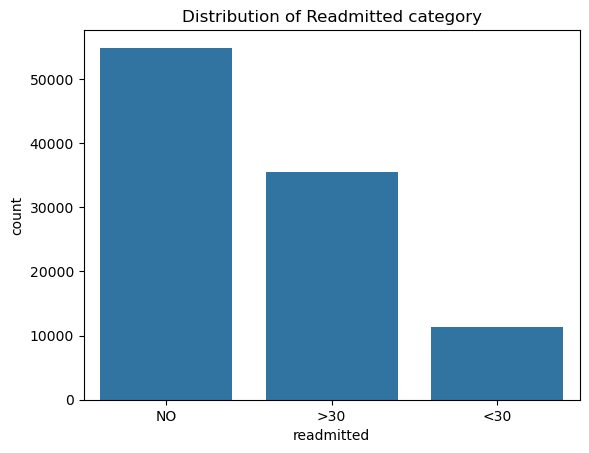

In [ ]:
#1.What is the distribution of the readmission category, with particular focus on whether a
# patient was readmitted within 30 days of discharge

sns.countplot(df_selected,x="readmitted") 
plt.title("Distribution of Readmitted category")

Most patients were readmitted (164,952 cases), while fewer were readmitted within 30 days. A significant number were readmitted after 30 days (106,635 cases), indicating more late readmissions than early ones.

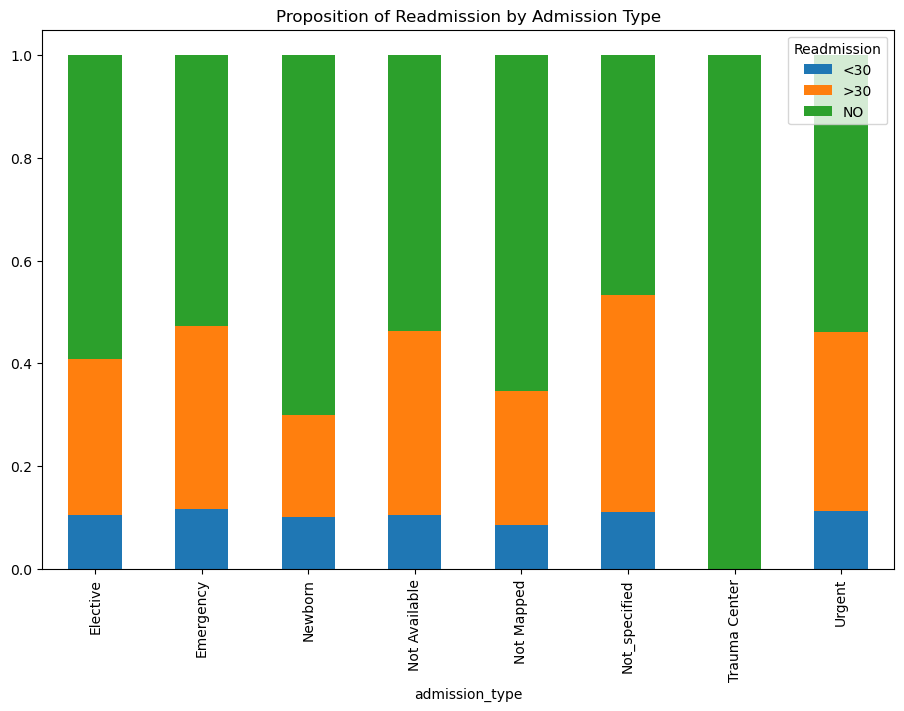

In [ ]:
#2. How does the readmission category vary by admission type? In particular, which admission
#types have a higher proportion of early readmissions?**
df_adm_ty = pd.crosstab(df_selected["admission_type"],df_selected["readmitted"], normalize='index')
df_adm_ty.plot(kind="bar",stacked=True,figsize=(11,7))

plt.title("Proposition of Readmission by Admission Type")
plt.legend(title="Readmission")
plt.show()


The Emergency and Urgency is the one that is showing the highest proportion of readmission in less then 30 days. 
Trauma is higher proportion of NO admission, approximatly above 90%. 

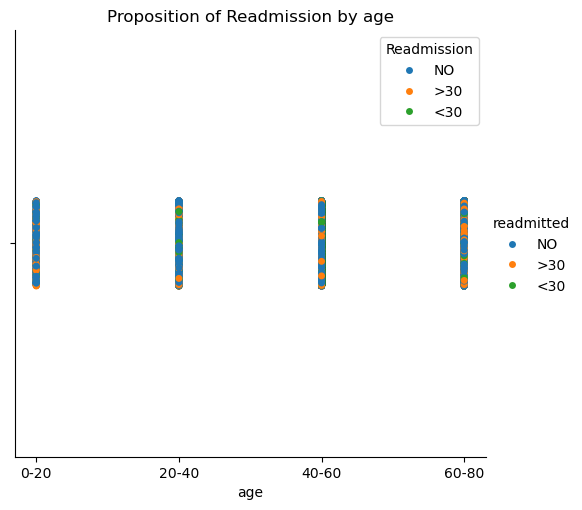

In [ ]:
#3. How does the readmission category vary across age group and gender?**
df_adm_ty = pd.crosstab(df_selected["age"],df_selected["readmitted"], normalize='index')
#df_adm_ty.plot(kind="bar",stacked=True,figsize=(11,7))
sns.catplot(data=df_selected,x="age",hue="readmitted")
plt.title("Proposition of Readmission by age")
plt.legend(title="Readmission")
plt.show()


Text(0.5, 1.0, 'Variation of Time in Hospital by Readmission')

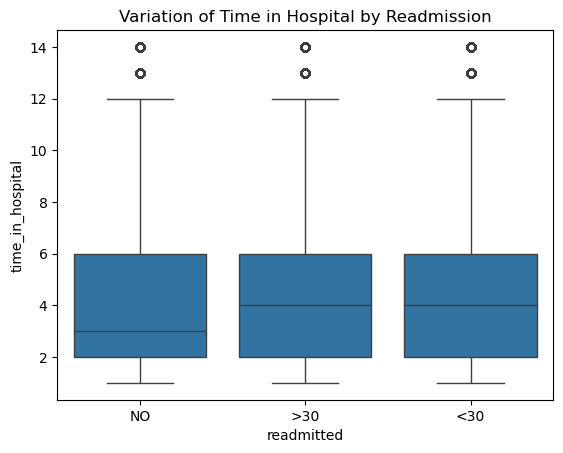

In [ ]:
#4. How does time in hospital vary across readmission categories? In particular, do patients
#readmitted within 30 days tend to have different lengths of stay?**
sns.boxplot(data=df_selected,x="readmitted",y="time_in_hospital")
plt.title("Variation of Time in Hospital by Readmission")

No, within 30 days and above days shows no difference in variation. 

Text(0.5, 1.0, 'Variation of Number of Medications by Readmission')

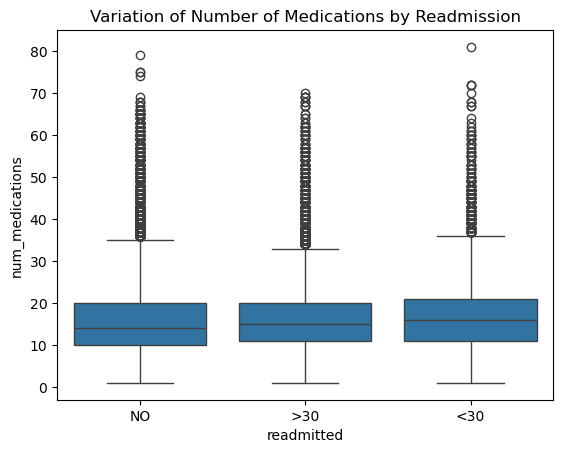

In [ ]:
#5. How does the distribution of the number of medications vary by readmission category?**
sns.boxplot(data=df_selected,x="readmitted",y="num_medications")
plt.title("Variation of Number of Medications by Readmission")

They don't show much difference in variation, although >30 days and <30 days have a slight higher median then NO readmission. 

In [ ]:
#6. How do treatment-intensity patterns, as measured by the average number of medications,
#vary across readmission categories and racial groups?**
df_race_readmit=df_selected.groupby(["race","readmitted"])["num_medications"].mean().reset_index()
#df_race_readmit
df_selected["race"].unique()

array([nan, 'Not_specified'], dtype=object)

In [ ]:
#7. How does the proportion of early readmission vary by number of encounters per patient?
#This visualisation must be based on unique patients rather than on encounter-level rows.**


In [ ]:
#8. Which medical specialty most frequently admits these patients?
#For this visualisation, you may exclude missing, unknown, or invalid medical specialty
#values, provided that your decision is clearly justified and documented.**
